# Import Libraries

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.layers import Reshape
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# Load Images

In [3]:
def load_images(folder_path, image_size=(64,64)):
    data = []
    labels = []

    label = os.path.basename(folder_path)  # Extract the label from the folder name

    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        if os.path.isfile(img_path):  # Check if it is a file
            img = cv2.imread(img_path)
            if img is not None:  # Check if the image was read correctly
                img = cv2.resize(img, image_size)  # Resize images to a common size
                data.append(img)
                labels.append(label)

    return np.array(data), np.array(labels)

dataset_path = r"E:\Dataset\sugarcane white leaf disease\Indian UAV\Merged_Data"

# Load images for each type of chest X-ray
data_Healthy_Soyabean, labels_Healthy_Soyabean = load_images(os.path.join(dataset_path, 'Healthy_Soyabean'))
data_rust, labels_rust = load_images(os.path.join(dataset_path, 'rust'))
data_Soyabean_Mosaic, labels_Soyabean_Mosaic = load_images(os.path.join(dataset_path, 'Soyabean_Mosaic'))
data_Soyabean_Semilooper_Pest_Attack, labels_Soyabean_Semilooper_Pest_Attack = load_images(os.path.join(dataset_path, 'Soyabean_Semilooper_Pest_Attack'))

# Concatenate

In [5]:
All_data = np.concatenate([
    data_Healthy_Soyabean,
    data_rust,
    data_Soyabean_Mosaic,
    data_Soyabean_Semilooper_Pest_Attack
])

All_labels = np.concatenate([
    labels_Healthy_Soyabean,
    labels_rust,
    labels_Soyabean_Mosaic,
    labels_Soyabean_Semilooper_Pest_Attack
])

# Normalization

In [6]:
All_data_normalized = All_data / 255.0

# Encode and Split

In [7]:
label_encoder = LabelEncoder()
all_labels_encoded = label_encoder.fit_transform(All_labels)
train_data, test_data, train_labels, test_labels = train_test_split(
    All_data_normalized, all_labels_encoded, test_size=0.20, random_state=42
)

# Data Distribution

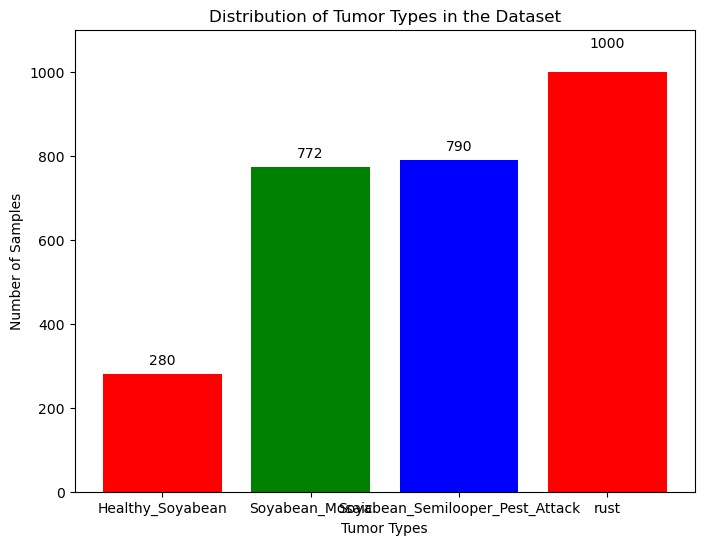

In [8]:
unique_labels, label_counts = np.unique(All_labels, return_counts=True)
plt.figure(figsize=(8, 6))

# Adjust ylim to create space between the outline and data level
plt.bar(unique_labels, label_counts, color=['red', 'green', 'blue'])
plt.xlabel('Tumor Types')
plt.ylabel('Number of Samples')
plt.title('Distribution of Tumor Types in the Dataset')

max_count = max(label_counts)  # Find the maximum count

# Adjust ylim to create space between the outline and data level
plt.ylim(0, max_count + 0.1 * max_count)

for i, count in enumerate(label_counts):
    plt.text(i, count + 0.05 * max_count, str(count), ha='center', va='bottom' if count > 0.9 * max_count else 'top')

#plt.xticks(unique_labels, ['glioma', 'meningioma', 'pituitary'])
plt.show()

# FPN

In [9]:
# --- Simple FPN feature extractor (64x64x3 input) ---
def build_simple_fpn_feature_extractor(input_shape=(64, 64, 3), fpn_channels=64):
    x_in = layers.Input(shape=input_shape)

    # Backbone (your 3 conv blocks)
    x = layers.Conv2D(18, 3, padding='same', activation='relu')(x_in)  # C3 base
    c3 = layers.MaxPooling2D(2)(x)   # 32x32x18

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(c3)    # C4 base
    c4 = layers.MaxPooling2D(2)(x)   # 16x16x32

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(c4)    # C5 base
    c5 = layers.MaxPooling2D(2)(x)   #  8x8x64

    # Lateral 1x1 to unify channels
    l3 = layers.Conv2D(fpn_channels, 1, padding='same')(c3)  # 32x32xF
    l4 = layers.Conv2D(fpn_channels, 1, padding='same')(c4)  # 16x16xF
    l5 = layers.Conv2D(fpn_channels, 1, padding='same')(c5)  #  8x8xF

    # Top-down pathway (nearest upsample + add)
    p5 = l5
    p4 = layers.Add()([l4, layers.UpSampling2D(2)(p5)])      # 8->16
    p3 = layers.Add()([l3, layers.UpSampling2D(2)(p4)])      # 16->32

    # Light 3x3 refinement (optional but common in FPN)
    p3 = layers.Conv2D(fpn_channels, 3, padding='same', activation='relu')(p3)
    p4 = layers.Conv2D(fpn_channels, 3, padding='same', activation='relu')(p4)
    p5 = layers.Conv2D(fpn_channels, 3, padding='same', activation='relu')(p5)

    # Convert to one vector for SVM: GAP each level and concat
    g3 = layers.GlobalAveragePooling2D()(p3)   # -> (F,)
    g4 = layers.GlobalAveragePooling2D()(p4)   # -> (F,)
    g5 = layers.GlobalAveragePooling2D()(p5)   # -> (F,)
    feat_vec = layers.Concatenate(name="fpn_feat")([g3, g4, g5])  # -> (3F,)

    return models.Model(x_in, feat_vec, name="simple_fpn_feature_extractor")

# === Replace your previous model with this one ===
cnn_model = build_simple_fpn_feature_extractor(input_shape=(64,64,3), fpn_channels=64)
cnn_model.summary()

Model: "simple_fpn_feature_extractor"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 64, 64, 3)]          0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 64, 64, 18)           504       ['input_1[0][0]']             
                                                                                                  
 max_pooling2d (MaxPooling2  (None, 32, 32, 18)           0         ['conv2d[0][0]']              
 D)                                                                                               
                                                                                                  
 conv2d_1 (Conv2D)           (None, 32, 32, 32)           5216      ['m

# Features Flattened

In [10]:
# Feature extraction (same usage pattern as your code)
train_features = cnn_model.predict(train_data, batch_size=64, verbose=0)
test_features  = cnn_model.predict(test_data,  batch_size=64, verbose=0)

# (Optional) L2 normalization helps SVMs
def l2_normalize(a, axis=1, eps=1e-12):
    return a / np.maximum(np.linalg.norm(a, axis=axis, keepdims=True), eps)

train_features = l2_normalize(train_features)
test_features  = l2_normalize(test_features)

# If you still want to "flatten" like before, it's already 2D (N, 3*fpn_channels).
# But this keeps compatibility with your original lines:
train_features_flattened = np.reshape(train_features, (train_features.shape[0], -1))
test_features_flattened  = np.reshape(test_features,  (test_features.shape[0], -1))

# SVC

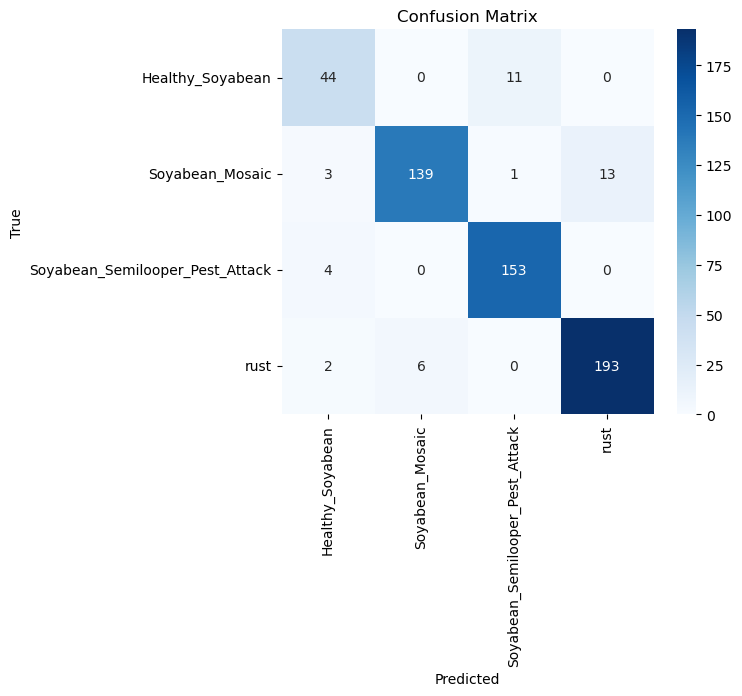

Classification Report:
                                  precision    recall  f1-score   support

               Healthy_Soyabean       0.83      0.80      0.81        55
                Soyabean_Mosaic       0.96      0.89      0.92       156
Soyabean_Semilooper_Pest_Attack       0.93      0.97      0.95       157
                           rust       0.94      0.96      0.95       201

                       accuracy                           0.93       569
                      macro avg       0.91      0.91      0.91       569
                   weighted avg       0.93      0.93      0.93       569



In [18]:
# 🧠 Step 1: Fit final model
final_model = SVC(C=25, kernel='rbf', gamma=1, probability=True, random_state=42)
final_model.fit(train_features_flattened, train_labels)

# 🚀 Step 2: Predictions
pred_labels = final_model.predict(test_features_flattened)
pred_probs = final_model.predict_proba(test_features_flattened)

# 📊 Step 3: Confusion Matrix
cm = confusion_matrix(test_labels, pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# 🧾 Step 4: Classification Report
print("Classification Report:\n", classification_report(test_labels, pred_labels, target_names=label_encoder.classes_))

In [20]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

for kernel in ['linear', 'poly', 'rbf', 'sigmoid']:
    print(f'Kernel: {kernel}')

    c_value = 0.1

    while c_value <= 50.0:
        svm_model = SVC(C=c_value, kernel=kernel, random_state=42)
        svm_model.fit(train_features_flattened, train_labels)
        predictions = svm_model.predict(test_features_flattened)
        accuracy = accuracy_score(test_labels, predictions)

        print(f'C: {c_value:.2f}, Accuracy: {accuracy * 100:.2f}')

        report = classification_report(test_labels, predictions, target_names=label_encoder.classes_)
        print('Classification Report:\n', report)
        c_value += 0.5

    print('-' * 50)

Kernel: linear
C: 0.10, Accuracy: 35.33
Classification Report:
                                  precision    recall  f1-score   support

               Healthy_Soyabean       0.00      0.00      0.00        55
                Soyabean_Mosaic       0.00      0.00      0.00       156
Soyabean_Semilooper_Pest_Attack       0.00      0.00      0.00       157
                           rust       0.35      1.00      0.52       201

                       accuracy                           0.35       569
                      macro avg       0.09      0.25      0.13       569
                   weighted avg       0.12      0.35      0.18       569



C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


C: 0.60, Accuracy: 75.04
Classification Report:
                                  precision    recall  f1-score   support

               Healthy_Soyabean       0.00      0.00      0.00        55
                Soyabean_Mosaic       0.69      0.64      0.66       156
Soyabean_Semilooper_Pest_Attack       0.89      0.89      0.89       157
                           rust       0.70      0.94      0.80       201

                       accuracy                           0.75       569
                      macro avg       0.57      0.62      0.59       569
                   weighted avg       0.68      0.75      0.71       569



C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


C: 1.10, Accuracy: 78.56
Classification Report:
                                  precision    recall  f1-score   support

               Healthy_Soyabean       1.00      0.02      0.04        55
                Soyabean_Mosaic       0.65      0.93      0.77       156
Soyabean_Semilooper_Pest_Attack       0.89      0.89      0.89       157
                           rust       0.86      0.81      0.83       201

                       accuracy                           0.79       569
                      macro avg       0.85      0.66      0.63       569
                   weighted avg       0.82      0.79      0.75       569

C: 1.60, Accuracy: 78.91
Classification Report:
                                  precision    recall  f1-score   support

               Healthy_Soyabean       1.00      0.04      0.07        55
                Soyabean_Mosaic       0.65      0.94      0.77       156
Soyabean_Semilooper_Pest_Attack       0.90      0.89      0.89       157
                      

...

C: 3.10, Accuracy: 77.68
Classification Report:
                                  precision    recall  f1-score   support

               Healthy_Soyabean       0.00      0.00      0.00        55
                Soyabean_Mosaic       0.64      0.91      0.75       156
Soyabean_Semilooper_Pest_Attack       0.89      0.89      0.89       157
                           rust       0.85      0.80      0.82       201

                       accuracy                           0.78       569
                      macro avg       0.59      0.65      0.62       569
                   weighted avg       0.72      0.78      0.74       569



C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


C: 3.60, Accuracy: 78.21
Classification Report:
                                  precision    recall  f1-score   support

               Healthy_Soyabean       0.00      0.00      0.00        55
                Soyabean_Mosaic       0.65      0.92      0.76       156
Soyabean_Semilooper_Pest_Attack       0.89      0.89      0.89       157
                           rust       0.85      0.81      0.83       201

                       accuracy                           0.78       569
                      macro avg       0.60      0.65      0.62       569
                   weighted avg       0.72      0.78      0.75       569



C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


C: 4.10, Accuracy: 78.56
Classification Report:
                                  precision    recall  f1-score   support

               Healthy_Soyabean       1.00      0.02      0.04        55
                Soyabean_Mosaic       0.65      0.93      0.76       156
Soyabean_Semilooper_Pest_Attack       0.90      0.89      0.89       157
                           rust       0.86      0.81      0.83       201

                       accuracy                           0.79       569
                      macro avg       0.85      0.66      0.63       569
                   weighted avg       0.82      0.79      0.75       569

C: 4.60, Accuracy: 78.56
Classification Report:
                                  precision    recall  f1-score   support

               Healthy_Soyabean       1.00      0.02      0.04        55
                Soyabean_Mosaic       0.65      0.93      0.76       156
Soyabean_Semilooper_Pest_Attack       0.90      0.89      0.89       157
                      

### C: 45.60, Accuracy: 96.49 Kernel: poly

In [24]:
# Fixed values
kernel = 'poly'
c_value =  45.60

# Gamma values to test
gamma_values = ['scale', 'auto', 0.001, 0.01, 0.1, 1, 2, 3, 4, 5, 10]

for gamma in gamma_values:
    print(f'\nKernel: {kernel}, C: {c_value}, Gamma: {gamma}')
    
    svm_model = SVC(C=c_value, kernel=kernel, gamma=gamma, random_state=42)
    svm_model.fit(train_features_flattened, train_labels)
    predictions = svm_model.predict(test_features_flattened)
    
    accuracy = accuracy_score(test_labels, predictions)
    print(f'Accuracy: {accuracy * 100:.2f}%')

    report = classification_report(test_labels, predictions, target_names=label_encoder.classes_)
    print('Classification Report:\n', report)

    print('-' * 50)


Kernel: poly, C: 45.6, Gamma: scale
Accuracy: 96.49%
Classification Report:
                                  precision    recall  f1-score   support

               Healthy_Soyabean       0.95      0.98      0.96        55
                Soyabean_Mosaic       0.98      0.92      0.95       156
Soyabean_Semilooper_Pest_Attack       0.99      0.97      0.98       157
                           rust       0.94      0.99      0.96       201

                       accuracy                           0.96       569
                      macro avg       0.96      0.97      0.96       569
                   weighted avg       0.97      0.96      0.96       569

--------------------------------------------------

Kernel: poly, C: 45.6, Gamma: auto
Accuracy: 35.33%
Classification Report:
                                  precision    recall  f1-score   support

               Healthy_Soyabean       0.00      0.00      0.00        55
                Soyabean_Mosaic       0.00      0.00      0.

C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Accuracy: 35.33%
Classification Report:
                                  precision    recall  f1-score   support

               Healthy_Soyabean       0.00      0.00      0.00        55
                Soyabean_Mosaic       0.00      0.00      0.00       156
Soyabean_Semilooper_Pest_Attack       0.00      0.00      0.00       157
                           rust       0.35      1.00      0.52       201

                       accuracy                           0.35       569
                      macro avg       0.09      0.25      0.13       569
                   weighted avg       0.12      0.35      0.18       569

--------------------------------------------------

Kernel: poly, C: 45.6, Gamma: 0.01


C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Accuracy: 35.33%
Classification Report:
                                  precision    recall  f1-score   support

               Healthy_Soyabean       0.00      0.00      0.00        55
                Soyabean_Mosaic       0.00      0.00      0.00       156
Soyabean_Semilooper_Pest_Attack       0.00      0.00      0.00       157
                           rust       0.35      1.00      0.52       201

                       accuracy                           0.35       569
                      macro avg       0.09      0.25      0.13       569
                   weighted avg       0.12      0.35      0.18       569

--------------------------------------------------

Kernel: poly, C: 45.6, Gamma: 0.1


C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Accuracy: 58.88%
Classification Report:
                                  precision    recall  f1-score   support

               Healthy_Soyabean       0.00      0.00      0.00        55
                Soyabean_Mosaic       0.00      0.00      0.00       156
Soyabean_Semilooper_Pest_Attack       0.92      0.85      0.89       157
                           rust       0.47      1.00      0.64       201

                       accuracy                           0.59       569
                      macro avg       0.35      0.46      0.38       569
                   weighted avg       0.42      0.59      0.47       569

--------------------------------------------------

Kernel: poly, C: 45.6, Gamma: 1


C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Accuracy: 94.90%
Classification Report:
                                  precision    recall  f1-score   support

               Healthy_Soyabean       0.89      0.91      0.90        55
                Soyabean_Mosaic       0.97      0.90      0.94       156
Soyabean_Semilooper_Pest_Attack       0.96      0.97      0.97       157
                           rust       0.94      0.98      0.96       201

                       accuracy                           0.95       569
                      macro avg       0.94      0.94      0.94       569
                   weighted avg       0.95      0.95      0.95       569

--------------------------------------------------

Kernel: poly, C: 45.6, Gamma: 2
Accuracy: 96.49%
Classification Report:
                                  precision    recall  f1-score   support

               Healthy_Soyabean       0.95      1.00      0.97        55
                Soyabean_Mosaic       0.96      0.94      0.95       156
Soyabean_Semilooper_Pest_At

### Kernel: poly, C: 45.6, Gamma: 5
### Accuracy: 97.19%

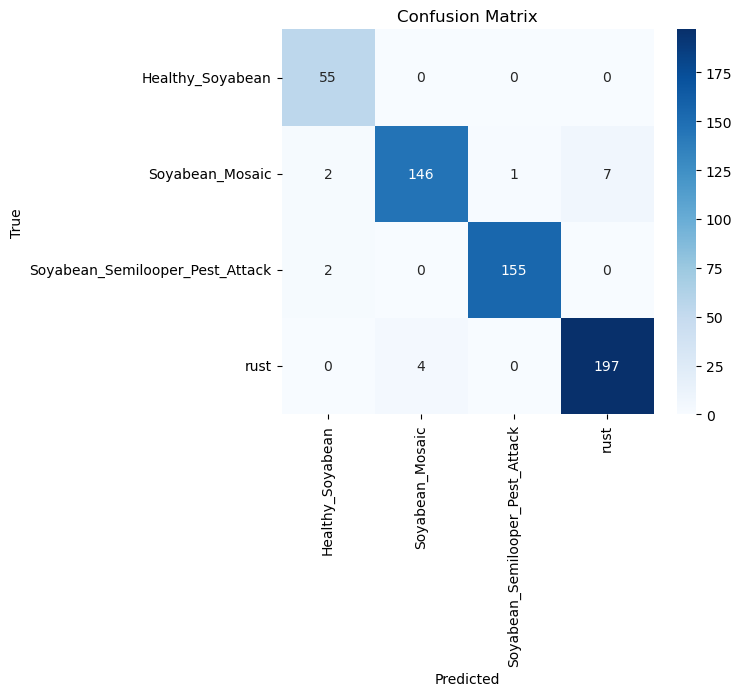

Classification Report:
                                  precision    recall  f1-score   support

               Healthy_Soyabean     0.9322    1.0000    0.9649        55
                Soyabean_Mosaic     0.9733    0.9359    0.9542       156
Soyabean_Semilooper_Pest_Attack     0.9936    0.9873    0.9904       157
                           rust     0.9657    0.9801    0.9728       201

                       accuracy                         0.9719       569
                      macro avg     0.9662    0.9758    0.9706       569
                   weighted avg     0.9722    0.9719    0.9718       569



In [114]:
# 🧠 Step 1: Fit final model
final_model = SVC(C=45.6, kernel='poly', gamma=5, probability=True, random_state=42)
final_model.fit(train_features_flattened, train_labels)

# 🚀 Step 2: Predictions
pred_labels = final_model.predict(test_features_flattened)
pred_probs = final_model.predict_proba(test_features_flattened)

# 📊 Step 3: Confusion Matrix
cm = confusion_matrix(test_labels, pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# 🧾 Step 4: Classification Report
print("Classification Report:\n", classification_report(test_labels, pred_labels, target_names=label_encoder.classes_,digits=4))

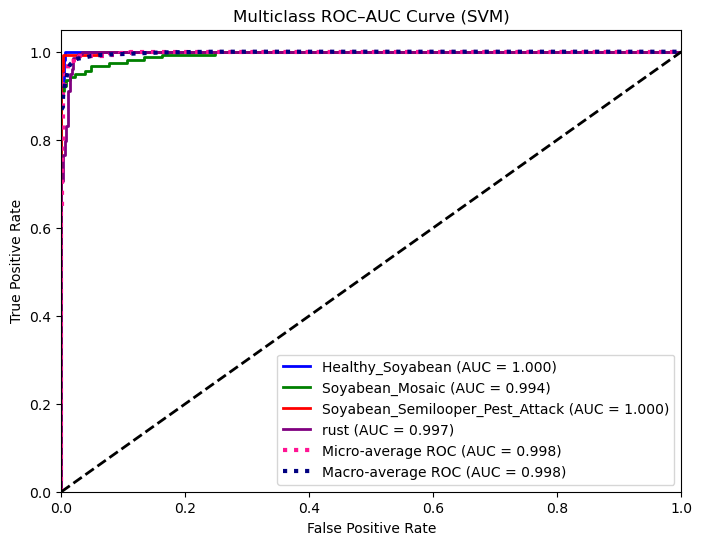

In [101]:
# 🔧 Binarize the labels for multiclass ROC
y_test_bin = label_binarize(test_labels, classes=range(num_classes))

y_pred_proba = pred_probs  

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# 📈 Plot ROC Curve
plt.figure(figsize=(8,6))
colors = ["blue", "green", "red", "purple"]  # one per class
for i, class_name in enumerate(label_encoder.classes_):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f"{class_name} (AUC = {roc_auc[i]:.3f})")

# Add micro/macro
plt.plot(fpr["micro"], tpr["micro"], color="deeppink", linestyle=":", linewidth=3,
         label=f"Micro-average ROC (AUC = {roc_auc['micro']:.3f})")
plt.plot(fpr["macro"], tpr["macro"], color="navy", linestyle=":", linewidth=3,
         label=f"Macro-average ROC (AUC = {roc_auc['macro']:.3f})")

plt.plot([0,1], [0,1], "k--", lw=2)  # diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC–AUC Curve (SVM)")
plt.legend(loc="lower right")
plt.show()

In [42]:
# import joblib
# joblib.dump(final_model, "svm_model_FPN.pkl")

['svm_model_FPN.pkl']

In [95]:
# svm = joblib.load("svm_model_FPN.pkl")
# rf  = joblib.load("rf_model_FPN.pkl")
# xgb = joblib.load("xgboost_model_FPN.pkl")

In [96]:
# # Predict probabilities (important for soft voting)
# p_svm = svm.predict_proba(test_features_flattened)
# p_rf  = rf.predict_proba(test_features_flattened)
# p_xgb = xgb.predict_proba(test_features_flattened)

In [99]:
# from sklearn.metrics import accuracy_score

# # Hard voting
# y_pred_hard = np.array([
#     np.argmax(np.bincount([svm.predict([x])[0],
#                            rf.predict([x])[0],
#                            xgb.predict([x])[0]]))
#     for x in test_features_flattened
# ])
# acc_hard = accuracy_score(test_labels, y_pred_hard)

# # Soft voting (your method)
# p_svm = svm.predict_proba(test_features_flattened)
# p_rf  = rf.predict_proba(test_features_flattened)
# p_xgb = xgb.predict_proba(test_features_flattened)
# P = (0.3 * p_svm + 0.3 * p_xgb + 0.4 * p_rf)
# y_pred_soft = np.argmax(P, axis=1)
# classes = svm.classes_
# y_pred_soft = classes[y_pred_soft]
# acc_soft = accuracy_score(test_labels, y_pred_soft)

# print("Hard Voting Accuracy:", acc_hard)
# print("Soft Voting Accuracy:", acc_soft)

Hard Voting Accuracy: 0.3936731107205624
Soft Voting Accuracy: 0.9437609841827768


In [91]:
# # Map back to class labels (all models should share same classes_)
# classes = svm.classes_
# y_pred = classes[y_pred]

# # Evaluate
# acc = accuracy_score(test_labels, y_pred)
# print("Ensemble accuracy:", acc)

Ensemble accuracy: 0.9437609841827768



Classification Report:
              precision    recall  f1-score   support

           0     0.9474    0.9818    0.9643        55
           1     0.8621    0.9615    0.9091       156
           2     0.9935    0.9682    0.9806       157
           3     0.9784    0.9005    0.9378       201

    accuracy                         0.9438       569
   macro avg     0.9453    0.9530    0.9480       569
weighted avg     0.9477    0.9438    0.9443       569


Confusion Matrix (rows=true, cols=pred):
[[ 54   1   0   0]
 [  1 150   1   4]
 [  2   3 152   0]
 [  0  20   0 181]]


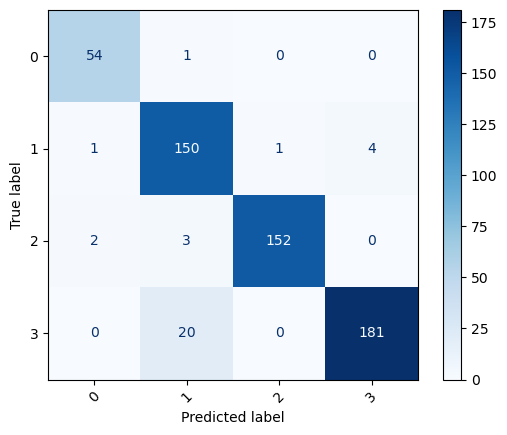

In [93]:
# from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# # Ensure classes is your desired order
# classes = svm.classes_

# # String versions for printing
# target_names = [str(c) for c in classes]

# print("\nClassification Report:")
# print(classification_report(
#     test_labels, y_pred,
#     labels=classes,                 # control row order
#     target_names=target_names,      # must be strings
#     digits=4,
#     zero_division=0                 # avoid div-by-zero warnings
# ))

# cm = confusion_matrix(test_labels, y_pred, labels=classes)
# print("\nConfusion Matrix (rows=true, cols=pred):")
# print(cm)

# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
# disp.plot(cmap="Blues", xticks_rotation=45)